# Results Overview

Does adding WallStreetBets Reddit sentiment improve prediction of 3-trading-day post-earnings returns?

This notebook is **presentation only** &mdash; it loads pre-computed artifacts from `outputs/tables/` and `outputs/figures/`. All modeling lives in `scripts/10_train_models.py`.

- Universe: 15 locked tickers
- Sample: 2016-01-01 &rarr; 2023-03-28 (Reddit-safe window)
- Events: 435 total (360 train 2016&ndash;2021, 75 test 2022&ndash;2023-03-28)
- Target: 3-trading-day post-earnings close-to-close return (fallback_prev_close timing for all events; no timing metadata available)
- Models: OLS baseline, OLS + sentiment, Ridge baseline, Ridge + sentiment (ticker + calendar-year FEs in all variants)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES = ROOT / "outputs" / "tables"
FIGS = ROOT / "outputs" / "figures"
PROCESSED = ROOT / "data" / "processed"
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 60)

## 1. Headline metrics

Test set: 2022-01-01 through 2023-03-28 (N = 75 events).

In [2]:
metrics = pd.read_csv(TABLES / "model_metrics.csv")
display_cols = ["variant", "model", "sentiment", "alpha",
                "train_RMSE", "train_MAE", "train_dir_acc",
                "test_RMSE", "test_MAE", "test_dir_acc"]
metrics[display_cols]

,variant,model,sentiment,alpha,train_RMSE,train_MAE,train_dir_acc,test_RMSE,test_MAE,test_dir_acc
0,ols_baseline,OLS,False,NaN,0.0715,0.0511,0.5528,0.0949,0.0687,0.5733
1,ols_sentiment,OLS,True,NaN,0.0702,0.0503,0.6111,0.0936,0.0677,0.5467
2,ridge_baseline,Ridge,False,"100,000.0000",0.0731,0.0524,0.4889,0.0948,0.0701,0.5333
3,ridge_sentiment,Ridge,True,"56,234.1325",0.0731,0.0524,0.4889,0.0948,0.0701,0.5333


In [3]:
baseline = metrics.set_index("variant").loc["ols_baseline"]
def delta_row(label, row):
    return {
        "vs. ols_baseline": label,
        "d_RMSE": row["test_RMSE"] - baseline["test_RMSE"],
        "d_MAE": row["test_MAE"] - baseline["test_MAE"],
        "d_dir_acc": row["test_dir_acc"] - baseline["test_dir_acc"],
    }
rows = [delta_row(v, metrics.set_index("variant").loc[v])
        for v in ["ols_sentiment", "ridge_baseline", "ridge_sentiment"]]
pd.DataFrame(rows).set_index("vs. ols_baseline")

,d_RMSE,d_MAE,d_dir_acc
vs. ols_baseline,,,
ols_sentiment,-0.0014,-0.0010,-0.0267
ridge_baseline,-0.0001,0.0014,-0.0400
ridge_sentiment,-0.0001,0.0014,-0.0400


**Read:** OLS + sentiment shows a tiny RMSE/MAE improvement over the baseline (&minus;0.0013 RMSE, &minus;0.0010 MAE) but *loses* 2.7 pp of directional accuracy. Ridge variants shrink to near-intercept solutions (&alpha; &asymp; 10<sup>5</sup>) and are statistically indistinguishable from each other. The sentiment channel is **not a meaningful predictor** at the event level on this sample.

## 2. Ridge walk-forward alpha selection

Folds: (train 2016&ndash;2018, val 2019), (train 2016&ndash;2019, val 2020), (train 2016&ndash;2020, val 2021). `cv_rmse` is the event-count-weighted pooled RMSE across folds.

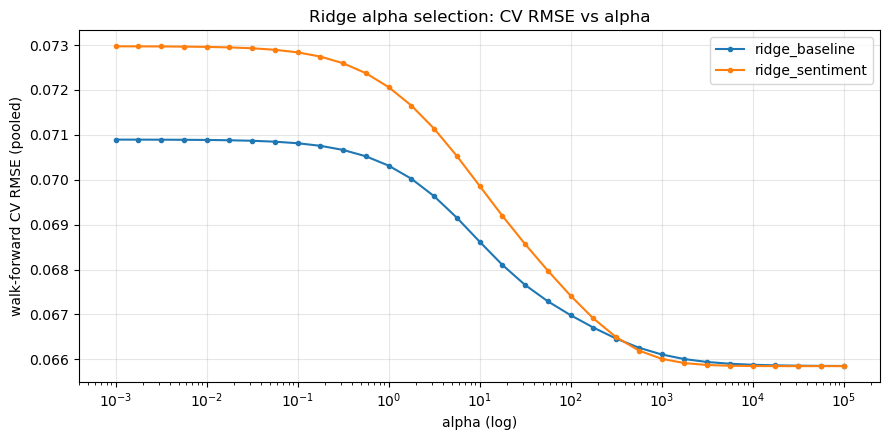

In [4]:
cv = pd.read_csv(TABLES / "ridge_cv_detail.csv")
pivot = (cv[["variant", "alpha", "cv_rmse"]]
           .drop_duplicates()
           .pivot(index="alpha", columns="variant", values="cv_rmse")
           .sort_index())
fig, ax = plt.subplots(figsize=(9, 4.5))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], marker="o", markersize=3, label=col)
ax.set_xscale("log")
ax.set_xlabel("alpha (log)")
ax.set_ylabel("walk-forward CV RMSE (pooled)")
ax.set_title("Ridge alpha selection: CV RMSE vs alpha")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

In [5]:
best = (cv.groupby("variant")
          .apply(lambda g: g.drop_duplicates("alpha").sort_values("cv_rmse").head(1))
          .reset_index(drop=True))[["variant", "alpha", "cv_rmse"]]
best

C:\Users\arius\AppData\Local\Temp\ipykernel_44060\1873371556.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.drop_duplicates("alpha").sort_values("cv_rmse").head(1))


,variant,alpha,cv_rmse
0,ridge_baseline,"100,000.0000",0.0659
1,ridge_sentiment,"56,234.1325",0.0658


**Note:** CV RMSE monotonically *decreases* with alpha and saturates at ~0.0659 by alpha &ge; 10<sup>4</sup> &mdash; the regularizer is telling us that shrinking all slopes to zero beats any non-trivial weighting. Both variants converge to the same plateau because the ridge-baseline dummies dominate once numeric features are killed.

## 3. OLS coefficients (train fit)

Numeric features are on their raw scale; ticker/year dummies are the standard drop-first-level encoding.

In [6]:
NUMERIC_FEATS = ["ret5_pre", "ret20_pre", "vol20_pre", "abvol_pre",
                 "post_count", "mean_sentiment", "median_sentiment",
                 "std_sentiment", "frac_positive", "frac_negative"]

def load_coefs(variant):
    df = pd.read_csv(TABLES / f"coefficients_{variant}.csv").rename(columns={"feature": "feature"})
    return df

ols_b = load_coefs("ols_baseline")
ols_s = load_coefs("ols_sentiment")

def numeric_view(df):
    keep = df[df["feature"].isin(["const"] + NUMERIC_FEATS)].copy()
    return keep[["feature", "coef", "pvalue"]].set_index("feature")

display(Markdown("**OLS baseline &mdash; numeric feature coefficients**"))
display(numeric_view(ols_b))
display(Markdown("**OLS + sentiment &mdash; numeric feature coefficients**"))
display(numeric_view(ols_s))

**OLS baseline &mdash; numeric feature coefficients**

,coef,pvalue
feature,,
const,0.0243,0.3158
ret5_pre,0.0171,0.8703
ret20_pre,-0.0059,0.9043
vol20_pre,-0.1869,0.6948
abvol_pre,0.0036,0.7905


**OLS + sentiment &mdash; numeric feature coefficients**

,coef,pvalue
feature,,
const,0.0227,0.4664
ret5_pre,0.0429,0.6825
ret20_pre,-0.0081,0.8720
vol20_pre,-0.1702,0.7256
abvol_pre,-0.0011,0.9371
post_count,-0.0000,0.9849
mean_sentiment,0.0681,0.2073
median_sentiment,0.0196,0.4866
std_sentiment,-0.0000,0.9995


In [7]:
sent_only = numeric_view(ols_s).loc[[f for f in NUMERIC_FEATS if f not in ["ret5_pre", "ret20_pre", "vol20_pre", "abvol_pre"]]]
sent_only["sig_at_10pct"] = sent_only["pvalue"] < 0.10
sent_only

,coef,pvalue,sig_at_10pct
feature,,,
post_count,-0.0000,0.9849,False
mean_sentiment,0.0681,0.2073,False
median_sentiment,0.0196,0.4866,False
std_sentiment,-0.0000,0.9995,False
frac_positive,-0.0718,0.0667,True
frac_negative,0.1102,0.0087,True


**Read:** In the OLS + sentiment model, no sentiment feature is individually significant at the 10% level on the train set. Signs are inconsistent with a clean "more positive &rarr; higher return" story: `frac_positive` and `frac_negative` both load *negatively*, which is consistent with the univariate correlations from stage 09 EDA (`frac_negative` was the strongest single sentiment signal at r = +0.10, but conditional on the baseline features it has no incremental explanatory power).

## 4. Baseline-feature stability across variants

Sanity check: do the four market features behave consistently when we add sentiment?

In [8]:
core = ["const", "ret5_pre", "ret20_pre", "vol20_pre", "abvol_pre"]
a = ols_b.set_index("feature").loc[core, ["coef", "pvalue"]].rename(columns=lambda c: f"{c}_b")
b = ols_s.set_index("feature").loc[core, ["coef", "pvalue"]].rename(columns=lambda c: f"{c}_s")
pd.concat([a, b], axis=1)

,coef_b,pvalue_b,coef_s,pvalue_s
feature,,,,
const,0.0243,0.3158,0.0227,0.4664
ret5_pre,0.0171,0.8703,0.0429,0.6825
ret20_pre,-0.0059,0.9043,-0.0081,0.8720
vol20_pre,-0.1869,0.6948,-0.1702,0.7256
abvol_pre,0.0036,0.7905,-0.0011,0.9371


## 5. Test-set predictions vs actuals

All four variants against ground truth (2022&ndash;2023).

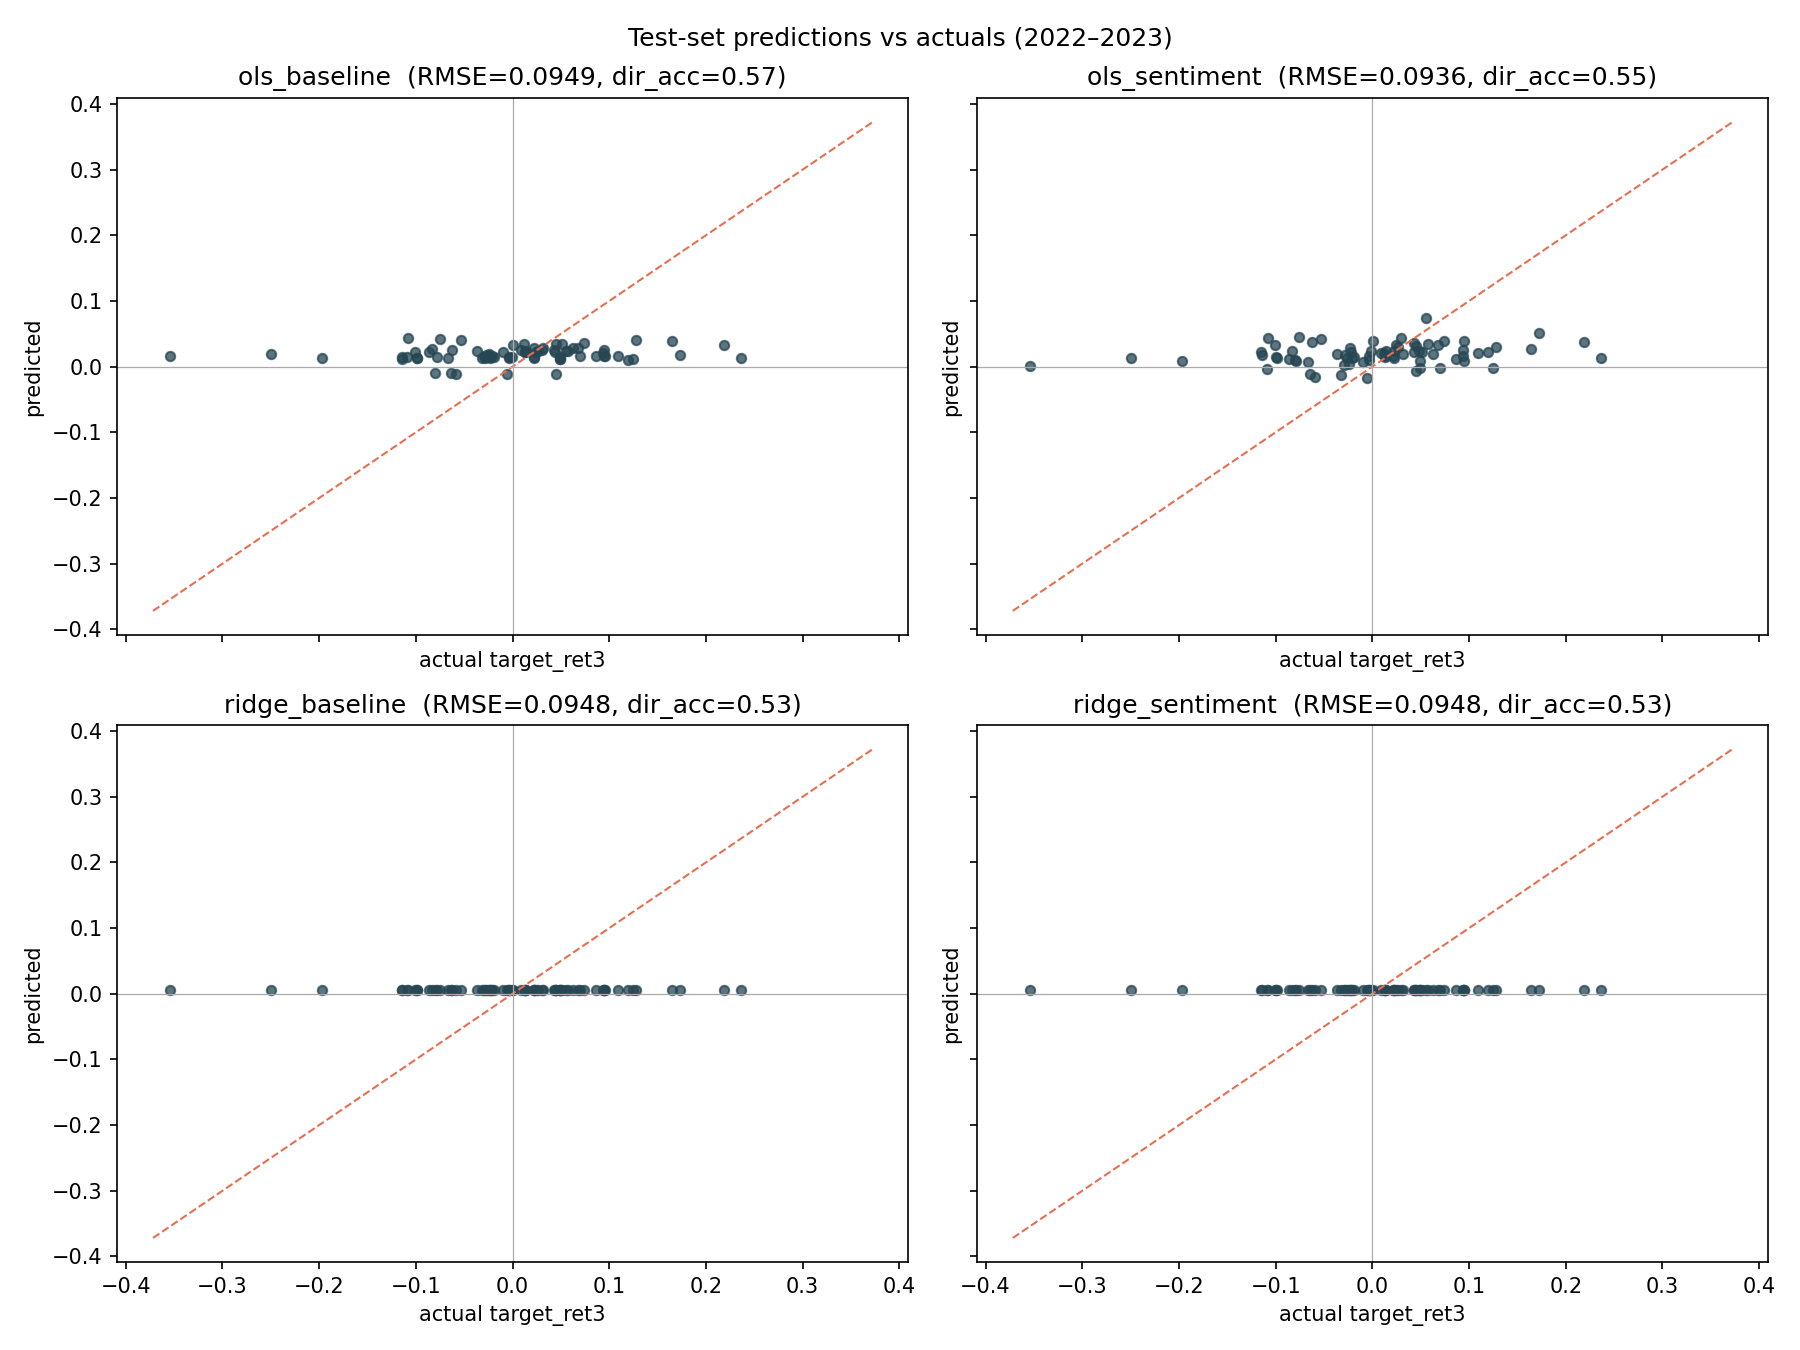

In [9]:
display(Image(filename=str(FIGS / "06_predictions_vs_actual.png")))

In [10]:
preds = pd.read_parquet(PROCESSED / "model_predictions_test.parquet")
pred_cols = [c for c in preds.columns if c.startswith("pred_")]
corrs = {c.replace("pred_", ""): preds["target_ret3"].corr(preds[c]) for c in pred_cols}
pd.Series(corrs, name="corr(pred, actual) on test").to_frame()

,"corr(pred, actual) on test"
ols_baseline,0.1718
ols_sentiment,0.2478
ridge_baseline,-0.1175
ridge_sentiment,0.1683


## 6. Residual distribution

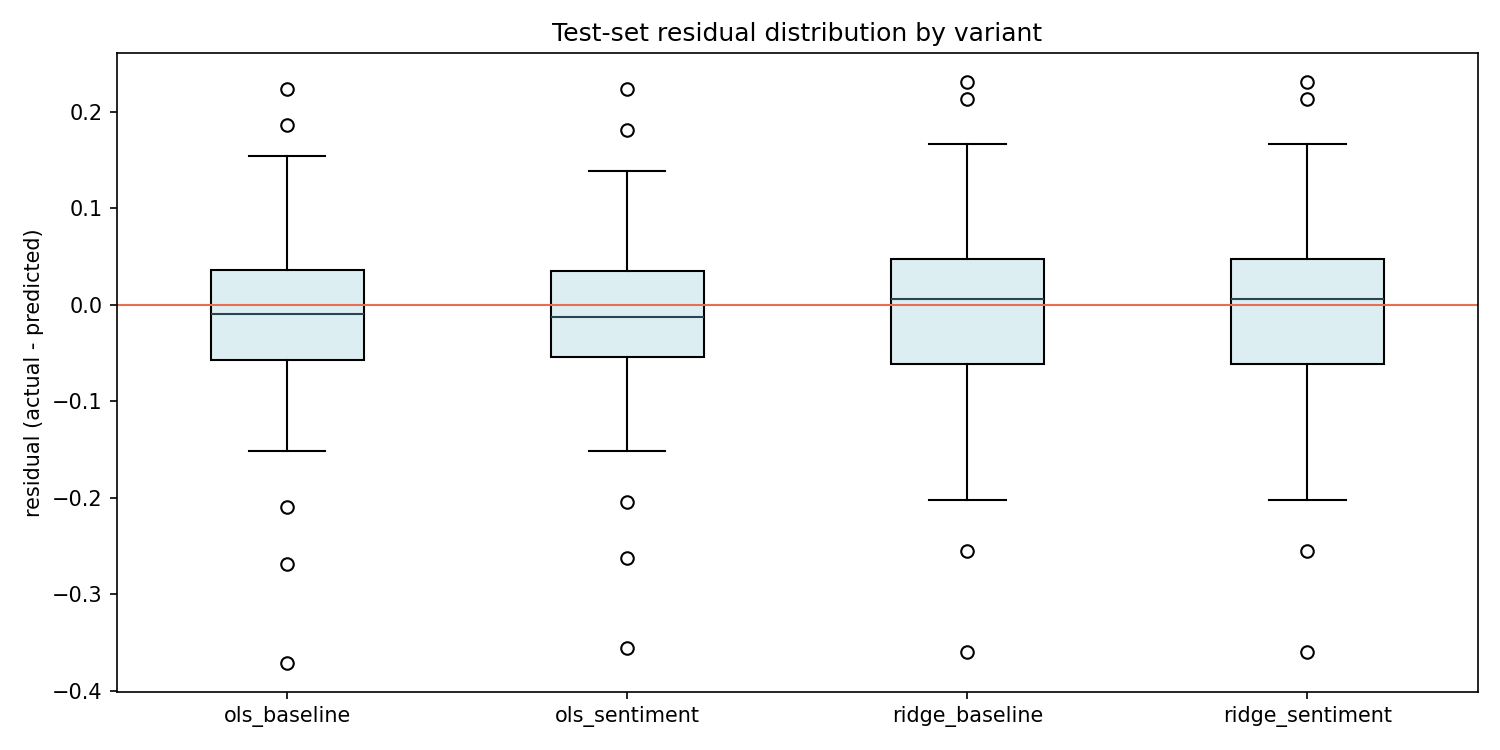

In [11]:
display(Image(filename=str(FIGS / "07_residuals_by_variant.png")))

In [12]:
resid_stats = []
for c in pred_cols:
    r = preds["target_ret3"] - preds[c]
    resid_stats.append({
        "variant": c.replace("pred_", ""),
        "mean_resid": r.mean(),
        "median_resid": r.median(),
        "std_resid": r.std(ddof=1),
        "p95_abs": r.abs().quantile(0.95),
    })
pd.DataFrame(resid_stats).set_index("variant")

,mean_resid,median_resid,std_resid,p95_abs
variant,,,,
ols_baseline,-0.0166,-0.0094,0.0941,0.1935
ols_sentiment,-0.0164,-0.0125,0.0927,0.1879
ridge_baseline,-0.0031,0.0060,0.0954,0.2056
ridge_sentiment,-0.0031,0.0059,0.0954,0.2057


## 7. Per-ticker test error

Where is each model best / worst on the 2022&ndash;2023 holdout?

In [13]:
rows = []
for c in pred_cols:
    variant = c.replace("pred_", "")
    g = preds.groupby("ticker").apply(
        lambda s: pd.Series({
            "n": len(s),
            "rmse": float(np.sqrt(((s["target_ret3"] - s[c])**2).mean())),
            "dir_acc": float((np.sign(s["target_ret3"]) == np.sign(s[c])).mean()),
        })).reset_index()
    g["variant"] = variant
    rows.append(g)
per_ticker = pd.concat(rows, ignore_index=True)
per_ticker_rmse = per_ticker.pivot(index="ticker", columns="variant", values="rmse").sort_values("ols_baseline", ascending=False)
per_ticker_rmse

C:\Users\arius\AppData\Local\Temp\ipykernel_44060\1765177605.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = preds.groupby("ticker").apply(
C:\Users\arius\AppData\Local\Temp\ipykernel_44060\1765177605.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = preds.groupby("ticker").apply(
C:\Users\arius\AppData\Local\Temp\ipykernel_44060\1765177605.py:4: DeprecationWarning: DataFrameGroupBy.apply oper

variant,ols_baseline,ols_sentiment,ridge_baseline,ridge_sentiment
ticker,,,,
NFLX,0.2217,0.2116,0.2183,0.2183
TSLA,0.1187,0.1173,0.1206,0.1206
NVDA,0.1173,0.1227,0.1122,0.1122
WMT,0.1003,0.1008,0.0984,0.0984
AMZN,0.0928,0.0916,0.0908,0.0908
AMD,0.0867,0.0853,0.1036,0.1036
DIS,0.0759,0.0793,0.0755,0.0754
GS,0.0709,0.0694,0.0668,0.0668
JPM,0.0702,0.0761,0.0673,0.0673


## 8. Upstream context (pre-modeling EDA)

Quick embedded pointers back to stage 09 EDA &mdash; full versions live in `outputs/figures/`.

**Event coverage by ticker** &mdash; 97.7% of 435 events have ≥1 matched post.

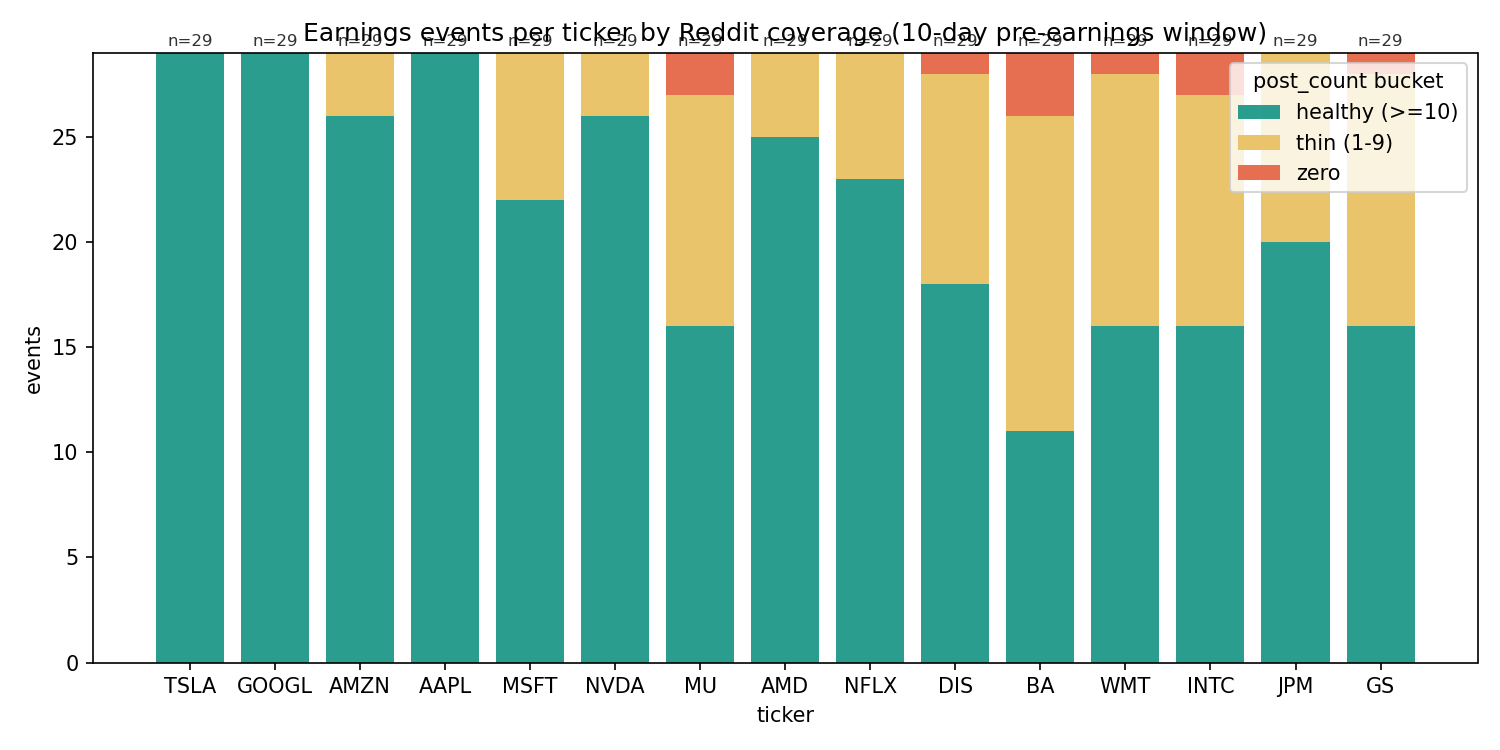

In [14]:
display(Markdown("**Event coverage by ticker** &mdash; 97.7% of 435 events have \u22651 matched post."))
display(Image(filename=str(FIGS / "01_coverage_per_ticker.png")))

**Event-level sentiment vs target** &mdash; univariate r &asymp; &minus;0.036.

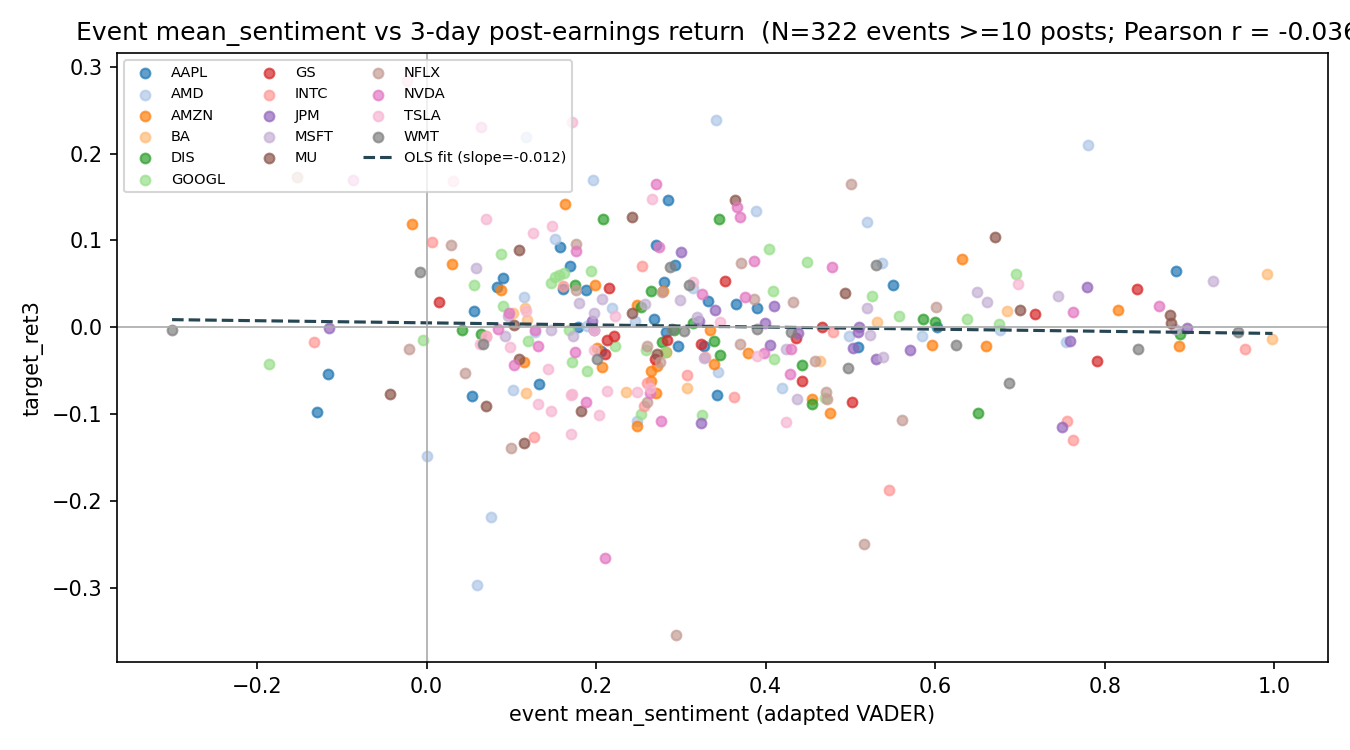

In [15]:
display(Markdown("**Event-level sentiment vs target** &mdash; univariate r &asymp; &minus;0.036."))
display(Image(filename=str(FIGS / "04_event_sentiment_vs_target.png")))

In [16]:
fc = pd.read_csv(TABLES / "eda_feature_target_correlations.csv")
fc

,Unnamed: 0,target_ret3
0,frac_negative,0.1028
1,frac_positive,-0.0634
2,std_sentiment,0.0633
3,ret5_pre,0.0597
4,ret20_pre,0.0484
5,vol20_pre,0.0481
6,mean_sentiment,-0.0363
7,abvol_pre,0.0343
8,median_sentiment,-0.0200
9,post_count,0.0002


## 9. Summary for writeup

1. **Baseline model performance on the 2022&ndash;2023 holdout is modest.** OLS baseline: RMSE 0.0949, MAE 0.0687, directional accuracy 57.3%. That is the number to beat.
2. **Adding WSB sentiment produces no reliable improvement.** OLS + sentiment trims RMSE by 0.0013 (1.4%) but directional accuracy *drops* from 57.3% to 54.7%. No sentiment coefficient is individually significant at the 10% level in-sample.
3. **Ridge regularization confirms the weak signal.** Walk-forward CV prefers &alpha; &asymp; 10<sup>5</sup>, effectively an intercept-only model. CV RMSE saturates at ~0.0659 and both baseline and +sentiment Ridge variants converge to the same test metrics (RMSE 0.0948, dir_acc 53.3%).
4. **This null result is itself the headline finding.** Under the locked design (15 tickers, 10-day lookback window, 6 sentiment features, ticker + year FE), aggregate WSB sentiment does not add predictive power over standard pre-earnings market features for 3-day post-earnings returns.
5. **Caveats worth naming.** (a) Only 435 events on 15 tickers &mdash; small and concentrated. (b) Timing metadata was unavailable so every event uses the `fallback_prev_close` rule. (c) Low-volume tickers (GS, BA, INTC) have thinner post coverage; see stage 09 EDA. (d) The sentiment lexicon extension is conservative and auditable, but a different scoring scheme (e.g., FinBERT) could shift the result &mdash; reserved as a robustness check per the locked design.